In [75]:
%%time
%matplotlib inline
import rioxarray
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import importlib 
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression

CPU times: total: 0 ns
Wall time: 0 ns


In [76]:
ndvi_array = np.load('../input/nonan_rung_ndvi.npy')
mean_ndvi = ndvi_array.mean(axis=0)
std_ndvi = ndvi_array.std(axis=0)
mean_ndvi

array([0.76231843, 0.79291505, 0.7392113 , 0.82060456, 0.83057517,
       0.7253528 , 0.7871257 , 0.7311653 , 0.72304153, 0.7231159 ,
       0.6745582 , 0.7490279 , 0.7585527 ], dtype=float32)

In [77]:
vh_array = np.load('../input/nonan_rung_vh.npy')
mean_vh = vh_array.mean(axis=0)
std_vh = vh_array.std(axis=0)
mean_vh

array([-14.83808044, -15.23241547, -15.05028118, -15.07798571,
       -14.93434064, -14.97416715, -15.06114554, -14.77127812,
       -14.77970662, -15.00208631, -14.90700902, -14.9851447 ,
       -14.9905614 ])

In [78]:
def draw(array, mean_vh, std_vh, name):
    plt.figure(figsize=(10, 6))
    columns_months = np.arange(13)
    # Vẽ từng đường của từng điểm
    for index, row in enumerate(array):
        plt.plot(columns_months, row, alpha=0.5)

    # Vẽ đường trung bình
    plt.plot(columns_months, mean_vh, color='red', marker='o', linewidth=2, label="Mean Trend")


    plt.fill_between(
        columns_months,
        mean_vh - std_vh,
        mean_vh + std_vh,
        color='pink',
        alpha=0.3,
        label="±1 Std Dev"
    )


    plt.legend()
    plt.xticks(rotation=45)
    plt.ylabel("Value")
    plt.xlabel("Time")
    plt.title(f"Trend {name} with Mean Line")
    plt.show()

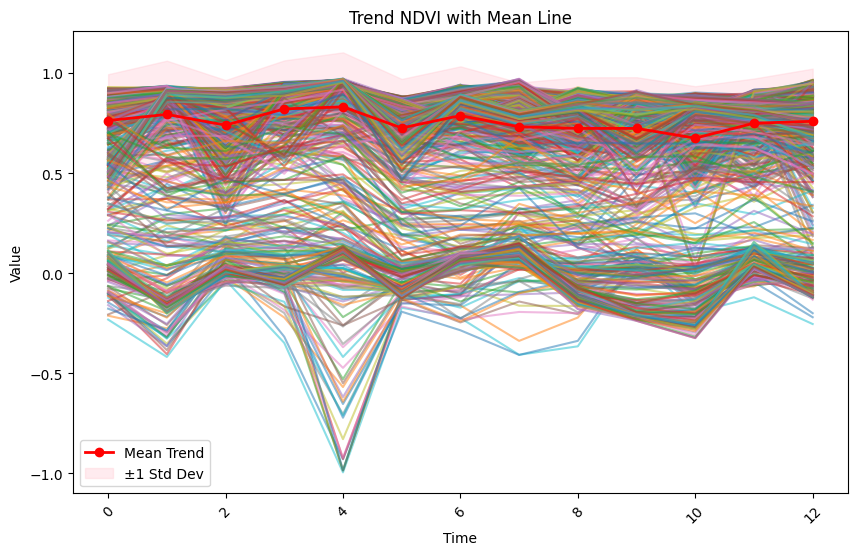

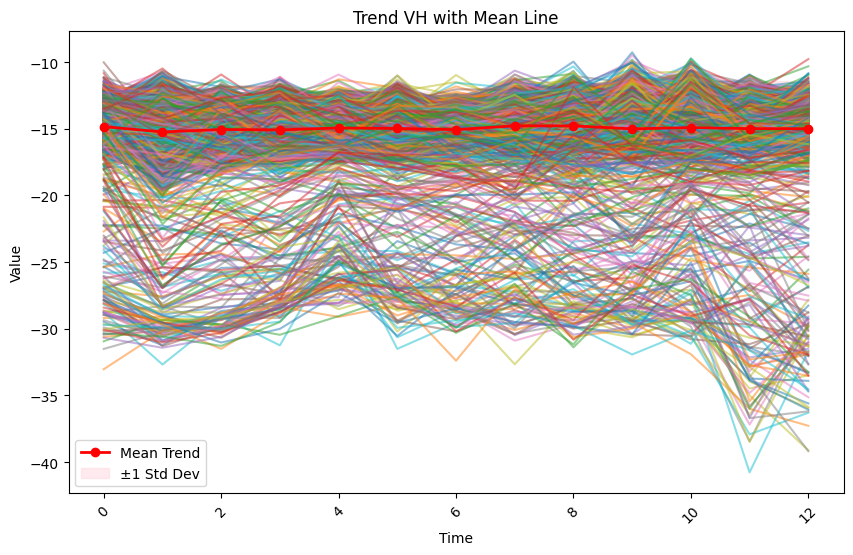

In [79]:
draw(ndvi_array, mean_ndvi, std_ndvi, "NDVI")
draw(vh_array, mean_vh, std_vh, "VH")

In [80]:
vh_array.shape

(2035, 13)

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# Tạo mảng lưu NDVI nội suy
ndvi_interp_data = np.zeros_like(ndvi_array)
scale_factors, interps = [], []
for i in range(vh_array.shape[0]):  # Lặp qua từng hàng (chuỗi thời gian)
    vh_fft = fft(vh_array[i])
    ndvi_fft = fft(ndvi_array[i])    
    # Tính hệ số tỷ lệ phổ
    scale_factor = np.abs(ndvi_fft) / (np.abs(vh_fft) + 1e-6)  # Tránh chia cho 0
    ndvi_interp_fft = vh_fft * scale_factor  # Áp dụng hệ số tỷ lệ
    scale_factors.append(scale_factor)
    interps.append(ndvi_interp_fft)
    # Nghịch biến đổi Fourier để khôi phục NDVI
    ndvi_interp_data[i] = np.real(ifft(ndvi_interp_fft)) + 1
    #print(scale_factor, ndvi_interp_fft)
    


In [82]:
scale_factors

[array([0.0490117 , 0.16658519, 0.05086933, 0.07903887, 0.05210932,
        0.1628133 , 0.40247467, 0.40247467, 0.1628133 , 0.05210932,
        0.07903887, 0.05086933, 0.16658519]),
 array([0.04345762, 1.00241135, 0.07234999, 0.1159649 , 0.04591866,
        0.06250993, 0.1569809 , 0.1569809 , 0.06250993, 0.04591866,
        0.1159649 , 0.07234999, 1.00241135]),
 array([0.05483463, 0.10237689, 0.04631971, 0.32606076, 0.17790972,
        0.19853166, 0.14179677, 0.14179677, 0.19853166, 0.17790972,
        0.32606076, 0.04631971, 0.10237689]),
 array([0.0520972 , 0.29468221, 0.08284119, 0.35322573, 0.1645957 ,
        0.12069148, 0.1434494 , 0.1434494 , 0.12069148, 0.1645957 ,
        0.35322573, 0.08284119, 0.29468221]),
 array([0.06049377, 0.23943083, 0.15405297, 0.16113986, 0.10629084,
        0.09520653, 0.05077478, 0.05077478, 0.09520653, 0.10629084,
        0.16113986, 0.15405297, 0.23943083]),
 array([0.06014102, 0.11253912, 0.1053018 , 0.12509101, 0.10241192,
        0.07207895, 0.

In [83]:
mean_scales = np.mean(scale_factors, axis=0)
mean_scales

array([0.05340248, 0.14483497, 0.08791697, 0.09518299, 0.08657447,
       0.12478728, 0.09386018, 0.09386018, 0.12478728, 0.08657447,
       0.09518299, 0.08791697, 0.14483497])

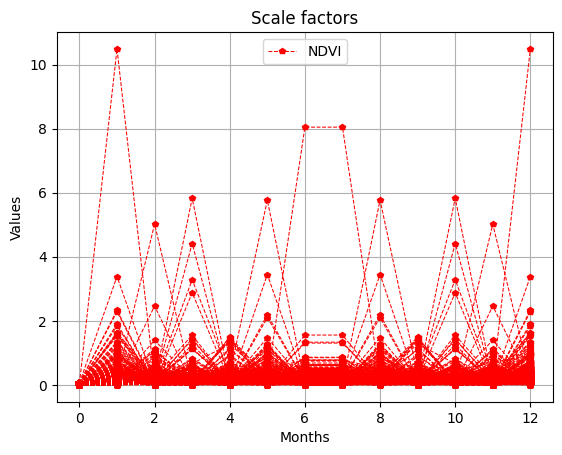

In [84]:
months = np.arange(13)
def draw_vh(scale_factors):
    for i, vh in enumerate(scale_factors[:]):
        plt.plot(months, vh, marker='p', ls="--", color="r", ms=4, lw=0.75, label='NDVI' if i == 0 else "")
    plt.grid(True)
    plt.legend(loc='best')
    plt.xlabel('Months')
    plt.ylabel('Values')
    plt.title(f'Scale factors')

draw_vh(scale_factors)

In [85]:
bias_range = np.arange(-5, 5, 0.01)
best_biases = np.zeros(vh_array.shape[0])

for i in range(vh_array.shape[0]):
    min_loss = float('inf')
    best_bias = 0
    scale_factor = np.abs(fft(ndvi_array[i])) / (np.abs(fft(vh_array[i])) + 1e-6)
    
    for bias in bias_range:
        ndvi_interp_fft = fft(vh_array[i]) * scale_factor
        ndvi_interp = np.real(ifft(ndvi_interp_fft)) + bias
        loss = np.mean((ndvi_interp - ndvi_array[i])**2)
        if loss < min_loss:
            min_loss = loss
            best_bias = bias
    
    best_biases[i] = best_bias
    ndvi_interp_data[i] = np.real(ifft(fft(vh_array[i]) * scale_factor)) + best_bias

In [86]:
best_bias

np.float64(-1.0658141036401503e-13)

In [87]:
# for i in range(vh_data.shape[0]):
#     plt.figure(figsize=(10, 6))
#     plt.plot(t, ndvi_data[i], label='NDVI Thực tế')
#     plt.plot(t, ndvi_interp_data[i], label='NDVI Suy ra')
#     plt.xlabel('Thời gian')
#     plt.ylabel('NDVI')
#     plt.legend()
#     plt.show()